In [1]:
#setup with all imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#formatting 
pd.options.display.float_format="{:,.2f}".format
pd.options.display.max_columns=None


In [2]:
#Initial Setup and Review of Data Set 
 
#get all the data sets

customers = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_customers_dataset.csv")
order_items = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_products_dataset.csv")
sellers = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/product_category_name_translation.csv")


orders = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_orders_dataset.csv")
geolocation = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_geolocation_dataset.csv")


#develop a master df

df = (orders
      .merge(customers, on='customer_id', how='left')
      .merge(order_items, on='order_id', how='left')
      .merge(order_payments, on='order_id', how='left')
      .merge(order_reviews, on='order_id', how='left')
      .merge(products, on='product_id', how='left')
      .merge(sellers, on='seller_id', how='left')
      .merge(category_translation, on='product_category_name', how='left')
     )

#converting datetime as it is str

# Convert datetime columns
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

#get some info on this data set

print(f"✅ Master dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📦 Orders: {orders.shape[0]:,}")
print(f"👥 Unique Customers: {customers['customer_unique_id'].nunique():,}")
print(f"🏪 Unique Sellers: {sellers['seller_id'].nunique():,}")
print(f"⏰ Date Range: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")


✅ Master dataframe: 119,143 rows × 40 columns
📦 Orders: 99,441
👥 Unique Customers: 96,096
🏪 Unique Sellers: 3,095
⏰ Date Range: 2016-09-04 → 2018-10-17


++++ NEW AND REPEAT CUSTOMR 

In [3]:
#Count of NEW & REPEAT customer  

#clean the dataset as duplicates exist for orders (why? mergered order_ietms and order_paymetns, have dupliacte rows per order (1 per item and payment installment)

# Keep only unique customer-order combinations
orders_clean = df[['customer_unique_id', 
                   'order_id', 
                   'order_purchase_timestamp',
                   'payment_value']].drop_duplicates()

#correcting the date-time
orders_clean['order_purchase_timestamp'] = pd.to_datetime(
    orders_clean['order_purchase_timestamp'])


customer_orders = (
    orders_clean
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

customer_orders['customer_type'] = customer_orders['total_orders'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)

print(f"👥 Customers: {customer_orders['customer_type'].value_counts()}")

👥 Customers: customer_type
New       93099
Repeat     2997
Name: count, dtype: int64


In [4]:
#Revenue New and Repeat 

# First aggregate revenue per order
order_revenue = (
    orders_clean
    .groupby(['customer_unique_id', 'order_id'])['payment_value']
    .sum()
    .reset_index()
)

# Then aggregate per customer
customer_revenue = (
    order_revenue
    .groupby('customer_unique_id')['payment_value']
    .sum()
    .reset_index()
)

# Merge with customer type
customer_analysis = customer_orders.merge(customer_revenue, 
                                          on='customer_unique_id')



print(f"👥 Customers AVG Revenue: {customer_analysis.groupby('customer_type')['payment_value'].mean()}")
print("\n")
print(f"👥 Customers TOTAL Revenue: {customer_analysis.groupby('customer_type')['payment_value'].sum()}")

👥 Customers AVG Revenue: customer_type
New      161.64
Repeat   314.41
Name: payment_value, dtype: float64


👥 Customers TOTAL Revenue: customer_type
New      15,048,703.22
Repeat      942,299.62
Name: payment_value, dtype: float64


<Axes: xlabel='cohort_month'>

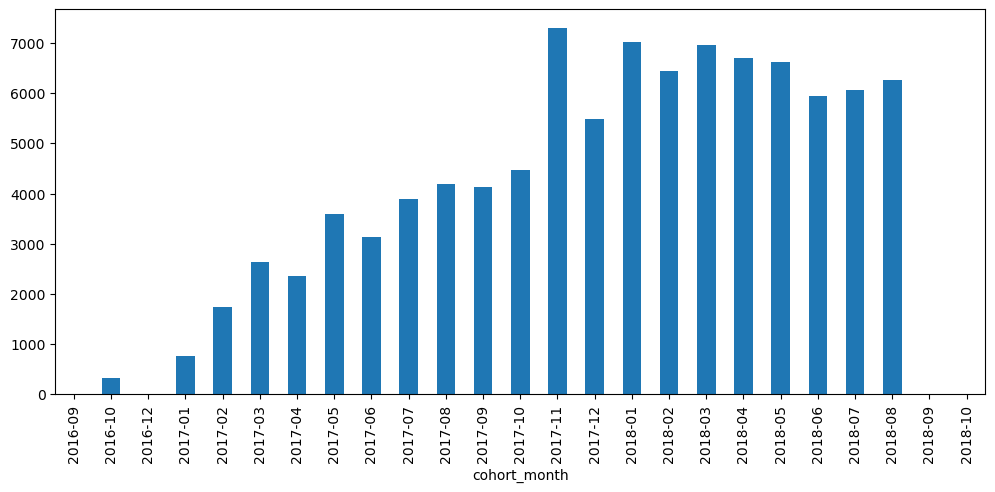

In [5]:
#Acqusition Trend Analysis 

first_purchase = (
    orders_clean
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

first_purchase['cohort_month'] = first_purchase['order_purchase_timestamp'].dt.to_period('M')

new_customers_by_month = first_purchase.groupby('cohort_month').size()

new_customers_by_month.plot(kind='bar', figsize=(12,5))

In [ ]:
### Comvert to CSV file 

#customer_analysis.to_csv(
#    "/Users/Julian/Desktop/IronHack/Final-Project/Data/Clean/customer_analysis.csv",
#    index=False,
#    encoding="utf-8"
#)

print("File saved successfully ✅")

File saved successfully ✅


#### DEVELOPING AN RFM SEGMENTATION 

In [7]:
#Selecting Data Points and Cleaning Data Set & Building RFM segments 

# Keep only relevant columns
rfm_df = df[['customer_unique_id',
             'order_id',
             'order_purchase_timestamp',
             'payment_value']].copy()

# Ensure datetime
rfm_df['order_purchase_timestamp'] = pd.to_datetime(rfm_df['order_purchase_timestamp'])

# Aggregate revenue per order (important because of duplicates)
rfm_df = (
    rfm_df
    .groupby(['customer_unique_id', 'order_id', 'order_purchase_timestamp'])['payment_value']
    .sum()
    .reset_index()
)

snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

#Setting up RFM DataFrame with relevant R-F_M coloums 
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

#Developing the Model 
## important note:
## 555 --> best customer 
## 111 --> worst customer 


rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str)
)



#Buliding the segments HV vs. LV ones
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] == 5 and row['M_score'] == 5:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['F_score'] >= 4:
        return 'Frequent Customers'
    elif row['M_score'] >= 4:
        return 'Big Spenders'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)


print(f"👥 RFM Segments - % Breakdown: {rfm['Segment'].value_counts(normalize=True) * 100}")
print("\n")
print(f"👥 RFM Segments - Revenue: {rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)}")


👥 RFM Segments - % Breakdown: Segment
Recent Customers     24.11
Frequent Customers   23.92
Others               22.21
Loyal Customers      15.03
Big Spenders         13.68
Champions             1.05
Name: proportion, dtype: float64


👥 RFM Segments - Revenue: Segment
Big Spenders         5,513,401.27
Frequent Customers   5,011,465.65
Recent Customers     4,779,557.01
Loyal Customers      2,954,326.04
Others               1,597,091.38
Champions              723,822.66
Name: Monetary, dtype: float64


In [8]:
### Comvert to CSV file 

#rfm.to_csv(
#    "/Users/Julian/Desktop/IronHack/Final-Project/Data/Clean/rfm.csv",
#    index=False,
#    encoding="utf-8"
#)

print("File saved successfully ✅")

File saved successfully ✅


+++ CLV 

++++ Historical CLV
- already have it ... 

CLV = Total Revenue / Customer 

In [ ]:



rfm[['customer_unique_id', 'Monetary']].head()

,customer_unique_id,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


++++ lets make it better 

CLV = Avg Order Value × Purchase Frequency × Customer Lifespan

In [48]:
#Develop CVL - Historical & Predictive

#step 1 : customer lifespan 

customer_lifespan = (
    rfm_df
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .agg(['min','max'])
    .reset_index()
)

customer_lifespan['lifespan_days'] = (
    customer_lifespan['max'] - customer_lifespan['min']
).dt.days

# Step 2: Calculate Average order vlaue
aov = (
    rfm_df
    .groupby('customer_unique_id')['payment_value']
    .mean()
    .reset_index()
    .rename(columns={'payment_value': 'avg_order_value'})
)

#Step 3: lets merge everything 
clv = rfm.merge(aov, on='customer_unique_id')
clv = clv.merge(customer_lifespan[['customer_unique_id','lifespan_days']],
                on='customer_unique_id')

#Step 4: Estimate CLV 

#simple version 
clv['CLV'] = clv['avg_order_value'] * clv['Frequency']


#advance version
clv['purchase_frequency_rate'] = clv['Frequency'] / clv['lifespan_days'].replace(0,1)

clv['CLV_advanced'] = (
    clv['avg_order_value'] *
    clv['purchase_frequency_rate'] *
    365
)

In [51]:
clv


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,avg_order_value,lifespan_days,CLV,purchase_frequency_rate,CLV_advanced
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414,Recent Customers,141.90,0,141.90,1.00,"51,793.50"
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,Recent Customers,27.19,0,27.19,1.00,"9,924.35"
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112,Others,86.22,0,86.22,1.00,"31,470.30"
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,Others,43.62,0,43.62,1.00,"15,921.30"
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214,Big Spenders,196.89,0,196.89,1.00,"71,864.85"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,"4,134.84",1,5,5,155,Frequent Customers,"4,134.84",0,"4,134.84",1.00,"1,509,216.60"
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,3,5,2,352,Frequent Customers,84.58,0,84.58,1.00,"30,871.70"
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46,1,5,3,153,Frequent Customers,112.46,0,112.46,1.00,"41,047.90"
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69,4,5,3,453,Loyal Customers,133.69,0,133.69,1.00,"48,796.85"


+++ Insights check 


In [37]:
rfm['Frequency'].value_counts(normalize=True)

Frequency
1     0.968812
2     0.028565
3     0.002112
4     0.000312
5     0.000083
6     0.000062
7     0.000031
9     0.000010
17    0.000010
Name: proportion, dtype: float64

In [38]:
rfm.shape[0]

96096

In [39]:
df['order_purchase_timestamp'].max()

'2018-10-17 17:30:18'

Developing the repeat purcahse rate not churn rate 

In [ ]:


# Ensure datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Define analysis date (last date in dataset)
analysis_date = df['order_purchase_timestamp'].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2018-10-17 17:30:18


In [41]:
# First purchase date per customer
first_purchase = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

print(first_purchase.head())
print("Total customers:", first_purchase.shape[0])

                 customer_unique_id order_purchase_timestamp
0  0000366f3b9a7992bf8c76cfdf3221e2      2018-05-10 10:56:27
1  0000b849f77a49e4a4ce2b2a4ca5be3f      2018-05-07 11:11:27
2  0000f46a3911fa3c0805444483337064      2017-03-10 21:05:03
3  0000f6ccb0745a6a4b88665a16c9f078      2017-10-12 20:29:41
4  0004aac84e0df4da2b147fca70cf8255      2017-11-14 19:45:42
Total customers: 96096


In [42]:
# Define cutoff (6 months before last date)
cutoff_date = analysis_date - pd.Timedelta(days=180)

print("Cutoff Date:", cutoff_date)

# Keep only customers whose first purchase was BEFORE cutoff
eligible_customers = first_purchase[
    first_purchase['order_purchase_timestamp'] <= cutoff_date
]

print("Eligible customers:", eligible_customers.shape[0])
print("Percentage eligible:", 
      round(eligible_customers.shape[0] / first_purchase.shape[0] * 100, 2), "%")

Cutoff Date: 2018-04-20 17:30:18
Eligible customers: 68940
Percentage eligible: 71.74 %


In [43]:
# Count total orders per customer
order_counts = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)

# Merge with eligible customers
customer_model_df = eligible_customers.merge(
    order_counts,
    on='customer_unique_id',
    how='left'
)

# Create repeat label
customer_model_df['repeat_buyer'] = (
    customer_model_df['order_id'] > 1
).astype(int)

print(customer_model_df['repeat_buyer'].value_counts())
print(customer_model_df['repeat_buyer'].value_counts(normalize=True))

repeat_buyer
0    66327
1     2613
Name: count, dtype: int64
repeat_buyer
0    0.962097
1    0.037903
Name: proportion, dtype: float64


In [45]:
#Step 5:

# Get first order ID per customer
first_orders = (
    df.sort_values('order_purchase_timestamp')
      .groupby('customer_unique_id')
      .first()
      .reset_index()
)

# Keep only eligible customers
first_orders = first_orders[
    first_orders['customer_unique_id'].isin(eligible_customers['customer_unique_id'])
]

print(first_orders.shape)
print(first_orders.head())

(68940, 40)
                 customer_unique_id                          order_id  \
2  0000f46a3911fa3c0805444483337064  b33ec3b699337181488304f362a6b734   
3  0000f6ccb0745a6a4b88665a16c9f078  41272756ecddd9a9ed0180413cc22fb6   
4  0004aac84e0df4da2b147fca70cf8255  d957021f1127559cd947b62533f484f7   
5  0004bd2a26a76fe21f786e4fbd80607f  3e470077b690ea3e3d501cffb5e0c499   
6  00050ab1314c0e55a6ca13cf7181fecf  d0028facea13f508e880202d7097a5a1   

                        customer_id order_status order_purchase_timestamp  \
2  9b3932a6253894a02c1df9d19004239f    delivered      2017-03-10 21:05:03   
3  914991f0c02ef0843c0e7010c819d642    delivered      2017-10-12 20:29:41   
4  47227568b10f5f58a524a75507e6992c    delivered      2017-11-14 19:45:42   
5  4a913a170c26e3c8052ed0202849b5a8    delivered      2018-04-05 19:33:16   
6  d2509c13692836fc0449e88cf9eb4858    delivered      2018-04-20 12:57:23   

     order_approved_at order_delivered_carrier_date  \
2  2017-03-10 21:05:03         

In [46]:
print(df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name_english'],
      dtype='object')


+++Financial Features - Enginnering part



In [47]:
# Financial features
first_orders['freight_ratio'] = first_orders['freight_value'] / first_orders['price']

# Handle division by zero just in case
first_orders['freight_ratio'] = first_orders['freight_ratio'].fillna(0)

first_orders[['price', 'freight_value', 'freight_ratio']].describe()

,price,freight_value,freight_ratio
count,68348.000000,68348.000000,68940.000000
mean,125.642479,19.743335,0.303622
std,187.972441,14.763537,0.297131
min,1.200000,0.000000,0.000000
25%,41.290000,13.440000,0.129597
50%,79.000000,16.120000,0.220862
75%,139.900000,20.700000,0.373942
max,6735.000000,409.680000,7.422846


In [48]:
date_cols = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    first_orders[col] = pd.to_datetime(first_orders[col])

In [49]:
# Delivery time (days)
first_orders['delivery_time_days'] = (
    first_orders['order_delivered_customer_date'] -
    first_orders['order_purchase_timestamp']
).dt.days

# Shipping time (days)
first_orders['shipping_time_days'] = (
    first_orders['order_delivered_carrier_date'] -
    first_orders['order_approved_at']
).dt.days

# Delivery delay (actual - estimated)
first_orders['delivery_delay_days'] = (
    first_orders['order_delivered_customer_date'] -
    first_orders['order_estimated_delivery_date']
).dt.days

# Late delivery flag
first_orders['late_delivery'] = (
    first_orders['delivery_delay_days'] > 0
).astype(int)

first_orders[['delivery_time_days',
              'shipping_time_days',
              'delivery_delay_days',
              'late_delivery']].describe()

,delivery_time_days,shipping_time_days,delivery_delay_days,late_delivery
count,66692.000000,67561.000000,66692.000000,68940.000000
mean,13.452573,2.629402,-11.365246,0.075936
std,11.905216,6.359169,12.033388,0.264897
min,0.000000,-249.000000,-147.000000,0.000000
25%,7.000000,1.000000,-17.000000,0.000000
50%,11.000000,2.000000,-12.000000,0.000000
75%,17.000000,3.000000,-8.000000,0.000000
max,520.000000,511.000000,499.000000,1.000000


In [50]:
# Merge repeat label
model_df = first_orders.merge(
    customer_model_df[['customer_unique_id', 'repeat_buyer']],
    on='customer_unique_id',
    how='left'
)

print(model_df.shape)
print(model_df['repeat_buyer'].value_counts())

(68940, 46)
repeat_buyer
0    66327
1     2613
Name: count, dtype: int64


+++ business intelligence modeling 



In [51]:
# Remove negative shipping times (data errors)
model_df = model_df[model_df['shipping_time_days'] >= 0]

# Remove extreme delivery times (cap at 99th percentile)
upper_cap = model_df['delivery_time_days'].quantile(0.99)
model_df = model_df[model_df['delivery_time_days'] <= upper_cap]

# Fill missing numeric values with median
numeric_cols = [
    'price', 'freight_value', 'freight_ratio',
    'delivery_time_days', 'shipping_time_days',
    'delivery_delay_days'
]

for col in numeric_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print("Final dataset shape:", model_df.shape)
print(model_df['repeat_buyer'].value_counts(normalize=True))

Final dataset shape: (65823, 46)
repeat_buyer
0    0.961548
1    0.038452
Name: proportion, dtype: float64


In [52]:
features = [
    'price',
    'freight_ratio',
    'delivery_time_days',
    'shipping_time_days',
    'delivery_delay_days',
    'late_delivery',
    'review_score',
    'product_weight_g',
    'product_photos_qty',
    'payment_installments'
]

X = model_df[features]
y = model_df['repeat_buyer']

In [54]:
# Check missing values in selected features
print(X.isna().sum())

price                      0
freight_ratio              0
delivery_time_days         0
shipping_time_days         0
delivery_delay_days        0
late_delivery              0
review_score             457
product_weight_g          13
product_photos_qty      1122
payment_installments       0
dtype: int64


In [55]:
# Fill missing numeric values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Confirm no missing values
print("Remaining missing values:")
print(X.isna().sum().sum())

Remaining missing values:
0


/var/folders/fy/lw4ygq8x06q_4mys1zs9j9zc0000gp/T/ipykernel_3179/1572688077.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.5813099348787792
              precision    recall  f1-score   support

           0       0.97      0.55      0.70     18988
           1       0.05      0.56      0.09       759

    accuracy                           0.55     19747
   macro avg       0.51      0.55      0.39     19747
weighted avg       0.93      0.55      0.68     19747



In [57]:
import numpy as np
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Odds_Ratio', ascending=False)

print(coefficients)

                Feature  Coefficient  Odds_Ratio
9  payment_installments     0.206420    1.229270
1         freight_ratio     0.044317    1.045314
5         late_delivery     0.040362    1.041187
3    shipping_time_days     0.036516    1.037191
6          review_score     0.014537    1.014643
7      product_weight_g    -0.020233    0.979971
4   delivery_delay_days    -0.056570    0.945000
2    delivery_time_days    -0.082570    0.920747
8    product_photos_qty    -0.124214    0.883191
0                 price    -0.229458    0.794964
